---
## Étape 1 — Exploration des parcours <a id='etape1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

# Chargement
touchpoints = pd.read_csv('touchpoints.csv')
campaigns   = pd.read_csv('campaigns.csv')

# Conversions types
touchpoints['timestamp']  = pd.to_datetime(touchpoints['timestamp'])
touchpoints['invoice_id'] = touchpoints['invoice_id'].astype('Int64')

print(f"touchpoints : {len(touchpoints):,} lignes | {touchpoints.shape[1]} colonnes")
print(f"campaigns   : {len(campaigns):,} lignes")
print()
print(f"Période            : {touchpoints['timestamp'].min().date()} -> {touchpoints['timestamp'].max().date()}")
print(f"Clients uniques    : {touchpoints['customer_id'].nunique():,}")
print(f"Campagnes          : {touchpoints['campaign_name'].unique().tolist()}")
print(f"Canaux             : {sorted(touchpoints['channel'].unique().tolist())}")
print(f"Taux de conversion : {touchpoints['converted'].mean()*100:.2f}%")

touchpoints : 692,782 lignes | 12 colonnes
campaigns   : 6 lignes

Période            : 2010-11-26 -> 2011-12-09
Clients uniques    : 47,834
Campagnes          : ['Summer_Sale', 'Back_to_School', 'Black_Friday', 'Winter_Promo', 'Valentine', 'Spring_Launch']
Canaux             : ['affiliate', 'direct', 'display', 'email', 'retargeting', 'search_paid', 'social']
Taux de conversion : 14.30%


In [2]:
display(touchpoints)

,touchpoint_id,customer_id,invoice_id,campaign_name,timestamp,channel,position,n_touchpoints,click,converted,cost,is_last_before_conversion
0,0,12346,<NA>,Summer_Sale,2011-01-12 13:53:03.779455317,affiliate,1,6,1,0,1.8698,0
1,1,12346,<NA>,Summer_Sale,2011-01-13 09:39:01.945606194,social,2,6,0,0,0.9344,0
2,2,12346,<NA>,Summer_Sale,2011-01-15 12:26:06.292806500,direct,3,6,1,0,0.0000,0
3,3,12346,<NA>,Summer_Sale,2011-01-16 04:17:18.063426214,affiliate,4,6,1,0,1.8373,0
4,4,12346,<NA>,Summer_Sale,2011-01-16 13:03:11.985655755,social,5,6,0,0,0.5099,0
...,...,...,...,...,...,...,...,...,...,...,...,...
692777,692777,63441,<NA>,Black_Friday,2011-05-11 23:20:57.696975078,email,1,2,1,0,0.0219,0
692778,692778,63441,<NA>,Black_Friday,2011-06-05 00:42:10.327257622,display,2,2,1,0,0.6346,0
692779,692779,63441,<NA>,Winter_Promo,2011-06-11 21:36:22.180796326,social,1,1,1,0,0.8666,0
692780,692780,63441,<NA>,Spring_Launch,2011-11-10 22:47:11.090521488,social,1,2,1,0,0.9898,0


In [3]:
# ── NETTOYAGE INITIAL ────────────────────────────────────────────────

print("=== AVANT NETTOYAGE ===")
print(f"Lignes : {len(touchpoints):,}")
print()

# 1. Valeurs manquantes
missing = touchpoints.isna().sum()
missing = missing[missing > 0]
print("Valeurs manquantes :")
print(missing if len(missing) > 0 else "  Aucune")
print()

# 2. Doublons exacts
n_dup = touchpoints.duplicated().sum()
print(f"Doublons exacts : {n_dup:,}")

# 3. Suppression des doublons
touchpoints = touchpoints.drop_duplicates()

# 4. invoice_id manquant = touchpoint sans conversion -> normal, on le documente
n_no_invoice = touchpoints['invoice_id'].isna().sum()
pct_no_invoice = n_no_invoice / len(touchpoints) * 100
print(f"Touchpoints sans invoice_id (non convertis) : {n_no_invoice:,} ({pct_no_invoice:.1f}%) -> normal")

# 5. Coûts négatifs ou aberrants
n_neg_cost = (touchpoints['cost'] < 0).sum()
print(f"Coûts négatifs : {n_neg_cost:,}")

# 6. Positions incohérentes (position > n_touchpoints)
n_pos_incoherent = (touchpoints['position'] > touchpoints['n_touchpoints']).sum()
print(f"Positions incohérentes (pos > n_touchpoints) : {n_pos_incoherent:,}")

print()
print("=== APRÈS NETTOYAGE ===")
print(f"Lignes : {len(touchpoints):,}")

=== AVANT NETTOYAGE ===
Lignes : 692,782

Valeurs manquantes :
invoice_id    593686
dtype: int64

Doublons exacts : 0
Touchpoints sans invoice_id (non convertis) : 593,686 (85.7%) -> normal
Coûts négatifs : 0
Positions incohérentes (pos > n_touchpoints) : 0

=== APRÈS NETTOYAGE ===
Lignes : 692,782


### 1.1 Touchpoints par client — distribution

=== Touchpoints par client ===
count    47834.00
mean        14.48
std         36.84
min          1.00
25%          4.00
50%          7.00
75%         14.00
90%         29.00
95%         46.00
99%        120.00
max       1559.00
Name: n_tp, dtype: float64

Médiane  : 7.0
Moyenne  : 14.5
Max      : 1559
Clients avec 1 seul touchpoint : 2,249 (4.7%)
Clients avec > 20 touchpoints  : 7,604 (15.9%)


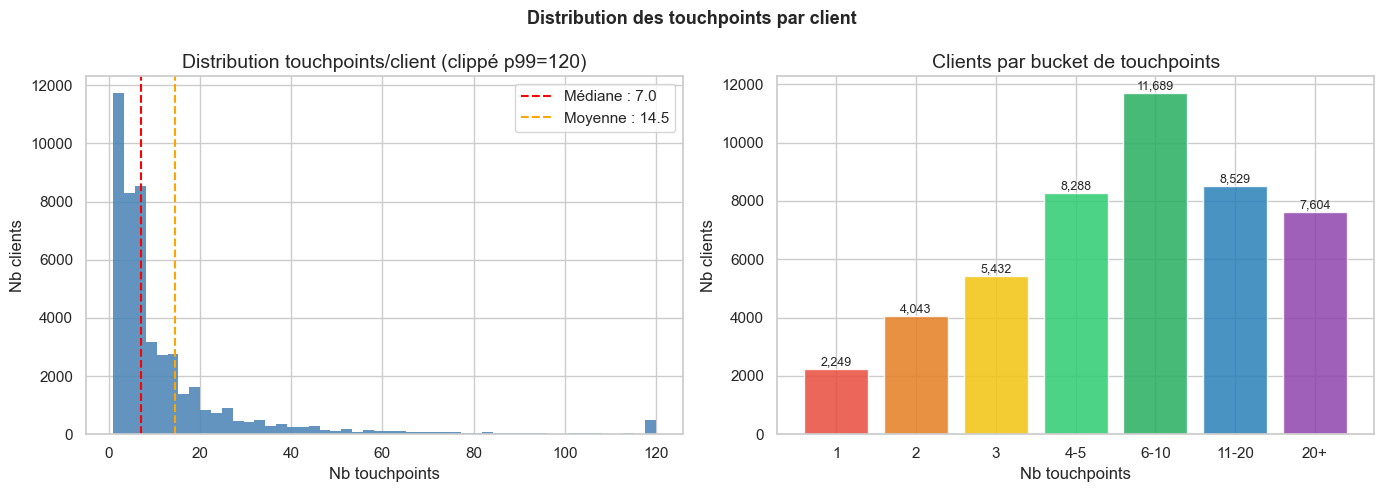

In [4]:
tp_per_client = touchpoints.groupby('customer_id')['touchpoint_id'].count().rename('n_tp')

print("=== Touchpoints par client ===")
print(tp_per_client.describe(percentiles=[.25,.5,.75,.90,.95,.99]).round(2))
print()
print(f"Médiane  : {tp_per_client.median():.1f}")
print(f"Moyenne  : {tp_per_client.mean():.1f}")
print(f"Max      : {tp_per_client.max()}")
print(f"Clients avec 1 seul touchpoint : {(tp_per_client==1).sum():,} ({(tp_per_client==1).mean()*100:.1f}%)")
print(f"Clients avec > 20 touchpoints  : {(tp_per_client>20).sum():,} ({(tp_per_client>20).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clip_val = int(tp_per_client.quantile(0.99))
axes[0].hist(tp_per_client.clip(upper=clip_val), bins=50,
             color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(tp_per_client.median(), color='red', linestyle='--',
                label=f'Médiane : {tp_per_client.median():.1f}')
axes[0].axvline(tp_per_client.mean(), color='orange', linestyle='--',
                label=f'Moyenne : {tp_per_client.mean():.1f}')
axes[0].set_title(f'Distribution touchpoints/client (clippé p99={clip_val})')
axes[0].set_xlabel('Nb touchpoints'); axes[0].set_ylabel('Nb clients')
axes[0].legend()

buckets = pd.cut(tp_per_client, bins=[0,1,2,3,5,10,20,tp_per_client.max()],
                 labels=['1','2','3','4-5','6-10','11-20','20+'])
bucket_counts = buckets.value_counts().sort_index()
colors_b = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60','#2980b9','#8e44ad']
bars = axes[1].bar(bucket_counts.index, bucket_counts.values, color=colors_b, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, bucket_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Clients par bucket de touchpoints')
axes[1].set_xlabel('Nb touchpoints'); axes[1].set_ylabel('Nb clients')

plt.suptitle('Distribution des touchpoints par client', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('tp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Durée moyenne des parcours

In [5]:
# Durée du parcours : premier touchpoint → is_last_before_conversion
converted_ids = touchpoints[touchpoints['converted']==1]['customer_id'].unique()
tp_conv = touchpoints[touchpoints['customer_id'].isin(converted_ids)]

first_touch_ts = tp_conv.groupby('customer_id')['timestamp'].min()
last_touch_ts  = tp_conv[tp_conv['is_last_before_conversion']==1].groupby('customer_id')['timestamp'].max()

journey_duration = (last_touch_ts - first_touch_ts).dt.total_seconds() / (60*60*24)

print("=== Durée des parcours (jours) ===")
print(journey_duration.describe(percentiles=[.25,.5,.75,.90]).round(2))
print()
print(f"Durée moyenne  : {journey_duration.mean():.1f} jours")
print(f"Durée médiane  : {journey_duration.median():.1f} jours")
print(f"Parcours < 1j  : {(journey_duration < 1).sum():,} ({(journey_duration < 1).mean()*100:.1f}%)")
print(f"Parcours > 30j : {(journey_duration > 30).sum():,} ({(journey_duration > 30).mean()*100:.1f}%)")

=== Durée des parcours (jours) ===
count    27753.00
mean       154.93
std        116.40
min          0.02
25%         27.57
50%        159.70
75%        258.35
90%        312.28
max        375.79
Name: timestamp, dtype: float64

Durée moyenne  : 154.9 jours
Durée médiane  : 159.7 jours
Parcours < 1j  : 309 (1.1%)
Parcours > 30j : 20,699 (74.6%)


### 1.3 Canaux en première et dernière position

Canal de premier contact :


,count,pct
channel,,
display,54131,28.6
social,54049,28.6
affiliate,53772,28.4
email,13709,7.2
retargeting,13582,7.2



Canal de dernier contact avant conversion :


,count,pct
channel,,
retargeting,24990,25.2
email,24777,25.0
direct,24693,24.9
search_paid,24636,24.9


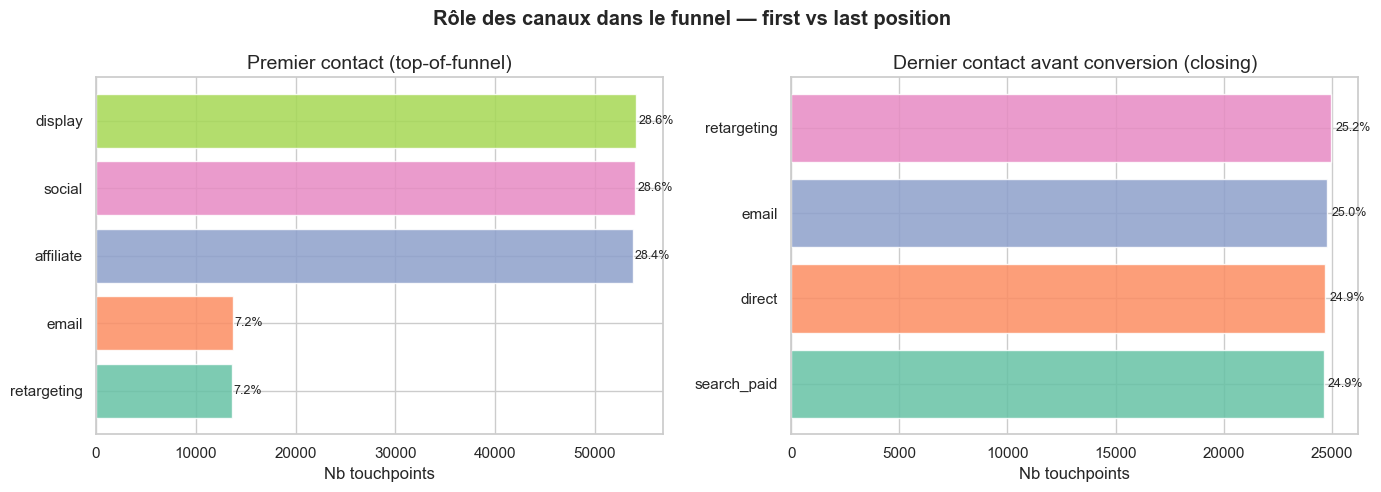

In [6]:
# Premier contact
first_touch_canal = touchpoints[touchpoints['position']==1]['channel'].value_counts()
print("Canal de premier contact :")
display(first_touch_canal.to_frame().assign(pct=lambda d: (d['count']/d['count'].sum()*100).round(1)))

# Dernier contact avant conversion
last_touch_canal = touchpoints[touchpoints['is_last_before_conversion']==1]['channel'].value_counts()
print("\nCanal de dernier contact avant conversion :")
display(last_touch_canal.to_frame().assign(pct=lambda d: (d['count']/d['count'].sum()*100).round(1)))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('Set2', 7)

axes[0].barh(first_touch_canal.index[::-1], first_touch_canal.values[::-1], color=palette, alpha=0.85)
axes[0].set_title('Premier contact (top-of-funnel)')
axes[0].set_xlabel('Nb touchpoints')
for i, (idx, val) in enumerate(first_touch_canal.sort_values().items()):
    axes[0].text(val+200, i, f'{val/first_touch_canal.sum()*100:.1f}%', va='center', fontsize=9)

axes[1].barh(last_touch_canal.index[::-1], last_touch_canal.values[::-1], color=palette, alpha=0.85)
axes[1].set_title('Dernier contact avant conversion (closing)')
axes[1].set_xlabel('Nb touchpoints')
for i, (idx, val) in enumerate(last_touch_canal.sort_values().items()):
    axes[1].text(val+200, i, f'{val/last_touch_canal.sum()*100:.1f}%', va='center', fontsize=9)

plt.suptitle('Rôle des canaux dans le funnel — first vs last position', fontweight='bold')
plt.tight_layout()
plt.savefig('first_last_touch.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Reconstruction des parcours & séquences récurrentes

In [7]:
# Reconstruction des parcours par client
parcours = []
for cust_id, group in touchpoints.groupby('customer_id'):
    group = group.sort_values('position')
    conv_positions = group[group['is_last_before_conversion']==1]['position'].values
    for conv_pos in conv_positions:
        chemin = group[group['position'] <= conv_pos]['channel'].tolist()
        parcours.append({
            'customer_id': cust_id,
            'conv_pos'   : conv_pos,
            'path'       : ' → '.join(chemin),
            'n_steps'    : len(chemin)
        })

paths_df = pd.DataFrame(parcours)
print(f"Parcours reconstruits : {len(paths_df):,}")
print(f"Parcours uniques      : {paths_df['path'].nunique():,}")
print()

for length in [1, 2, 3, 4, 5]:
    sub = paths_df[paths_df['n_steps']==length]
    top = sub['path'].value_counts().head(5)
    print(f"── {length} étape(s) : {len(sub):,} parcours")
    if len(sub)==0:
        print("  (aucun)")
    else:
        print(top.to_string())
    print()

Parcours reconstruits : 99,096
Parcours uniques      : 44,558

── 1 étape(s) : 0 parcours
  (aucun)

── 2 étape(s) : 1,074 parcours
path
display → email            102
social → retargeting        97
social → direct             96
social → email              94
affiliate → retargeting     94

── 3 étape(s) : 1,416 parcours
path
display → affiliate → email          26
display → affiliate → retargeting    26
display → display → retargeting      25
affiliate → direct → search_paid     25
social → display → direct            24

── 4 étape(s) : 2,169 parcours
path
social → social → email → search_paid              11
social → affiliate → email → email                 11
affiliate → display → email → retargeting          10
display → affiliate → search_paid → search_paid    10
display → retargeting → display → search_paid      10

── 5 étape(s) : 878 parcours
path
social → social → display → email → email             4
social → display → display → social → retargeting     3
social → affiliat

### 1.5 Longueur du parcours vs taux de conversion

Taux de conversion par longueur de parcours :


,length_bucket,n_clients,n_converted,conv_rate,conv_rate_pct
0,1,2249,0,0.000000,0.00
1,2,4043,1074,0.265644,26.56
2,3,5432,1416,0.260677,26.07
3,4-5,8288,2435,0.293798,29.38
4,6-10,11689,6695,0.572761,57.28
5,11-20,8529,8529,1.000000,100.00
6,21-50,5506,5506,1.000000,100.00
7,50+,2098,2098,1.000000,100.00


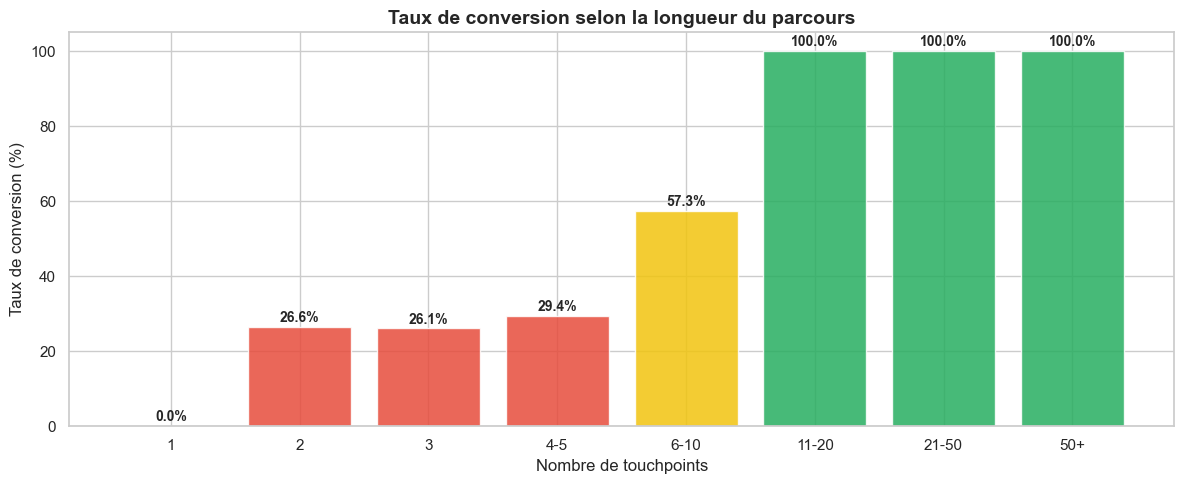

In [8]:
# Les parcours longs convertissent-ils mieux ?
# On prend tous les clients et leur nb de touchpoints
tp_stats = touchpoints.groupby('customer_id').agg(
    n_tp      = ('touchpoint_id', 'count'),
    converted = ('converted', 'max')
).reset_index()

tp_stats['length_bucket'] = pd.cut(
    tp_stats['n_tp'],
    bins=[0,1,2,3,5,10,20,50,tp_stats['n_tp'].max()],
    labels=['1','2','3','4-5','6-10','11-20','21-50','50+']
)

conv_by_length = tp_stats.groupby('length_bucket', observed=True).agg(
    n_clients     = ('customer_id','count'),
    n_converted   = ('converted','sum'),
    conv_rate     = ('converted','mean')
).reset_index()
conv_by_length['conv_rate_pct'] = (conv_by_length['conv_rate']*100).round(2)

print("Taux de conversion par longueur de parcours :")
display(conv_by_length)

fig, ax = plt.subplots(figsize=(12, 5))
colors_cv = ['#e74c3c' if r < 0.3 else '#27ae60' if r > 0.6 else '#f1c40f'
             for r in conv_by_length['conv_rate']]
bars = ax.bar(conv_by_length['length_bucket'], conv_by_length['conv_rate_pct'],
              color=colors_cv, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, conv_by_length['conv_rate_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Taux de conversion selon la longueur du parcours', fontweight='bold')
ax.set_xlabel('Nombre de touchpoints'); ax.set_ylabel('Taux de conversion (%)')
plt.tight_layout()
plt.savefig('conv_by_length.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Étape 2 — Modèles heuristiques <a id='etape2'></a>

4 modèles implémentés : **Last-touch**, **First-touch**, **Linéaire**, **Time-decay (décroissance temporelle)**

> **Principe** : chaque conversion (invoice_id) génère un crédit de 1.0 à répartir entre
> les canaux du parcours selon les règles de chaque modèle.


In [9]:
# Base : tous les touchpoints avec leur parcours reconstruit
# On travaille sur les conversions identifiées (is_last_before_conversion == 1)

# Reconstruire avec timestamps pour time-decay
parcours_full = []
for cust_id, group in touchpoints.groupby('customer_id'):
    group = group.sort_values('position')
    conv_rows = group[group['is_last_before_conversion']==1]
    for _, conv_row in conv_rows.iterrows():
        conv_pos = conv_row['position']
        chemin_df = group[group['position'] <= conv_pos][['channel','position','timestamp','cost']].copy()
        chemin_df['customer_id'] = cust_id
        chemin_df['conv_pos']    = conv_pos
        parcours_full.append(chemin_df)

all_paths = pd.concat(parcours_full, ignore_index=True)
print(f"Touchpoints dans les parcours de conversion : {len(all_paths):,}")
print(f"Conversions (parcours)                      : {all_paths.groupby(['customer_id','conv_pos']).ngroups:,}")

Touchpoints dans les parcours de conversion : 9,811,563
Conversions (parcours)                      : 48,557


In [10]:
# ── Vectorisé — tous les modèles en une passe ─────────────────────────

# Taille de chaque parcours
all_paths['n_steps'] = all_paths.groupby(['customer_id','conv_pos'])['position'].transform('count')

# Position inverse (pour time-decay et last/first touch)
all_paths['pos_rank']     = all_paths.groupby(['customer_id','conv_pos'])['position'].rank(method='first')
all_paths['pos_rank_rev'] = all_paths['n_steps'] - all_paths['pos_rank'] + 1  # 1 = dernier

# ── MODEL 1 : LAST-TOUCH ─────────────────────────────────────────────
# Crédit 1.0 uniquement au dernier touchpoint (pos_rank_rev == 1)
all_paths['credit_last'] = (all_paths['pos_rank_rev'] == 1).astype(float)
last_touch_credits = all_paths.groupby('channel')['credit_last'].sum().rename('last_touch')

# ── MODEL 2 : FIRST-TOUCH ────────────────────────────────────────────
# Crédit 1.0 uniquement au premier touchpoint (pos_rank == 1)
all_paths['credit_first'] = (all_paths['pos_rank'] == 1).astype(float)
first_touch_credits = all_paths.groupby('channel')['credit_first'].sum().rename('first_touch')

# ── MODEL 3 : LINÉAIRE ───────────────────────────────────────────────
# Crédit = 1 / n_steps pour chaque touchpoint du parcours
all_paths['credit_linear'] = 1.0 / all_paths['n_steps']
linear_credits = all_paths.groupby('channel')['credit_linear'].sum().rename('linear')

# ── MODEL 4 : TIME-DECAY (demi-vie = 7 jours) ────────────────────────
HALF_LIFE = 7

# Timestamp du dernier touchpoint par parcours
last_ts = (all_paths.groupby(['customer_id','conv_pos'])['timestamp']
           .transform('max'))

# Jours avant la conversion
all_paths['days_before'] = (last_ts - all_paths['timestamp']).dt.total_seconds() / 86400

# Poids brut
all_paths['weight_raw'] = np.power(0.5, all_paths['days_before'] / HALF_LIFE)

# Normalisation : diviser par la somme des poids du parcours
all_paths['weight_sum'] = all_paths.groupby(['customer_id','conv_pos'])['weight_raw'].transform('sum')
all_paths['credit_decay'] = all_paths['weight_raw'] / all_paths['weight_sum']

decay_credits = all_paths.groupby('channel')['credit_decay'].sum().rename('time_decay')

print("Crédits calculés pour les 4 modèles ✓")
print()
print("Vérification — somme des crédits par modèle (doit être égal au nb de conversions) :")
n_conv = all_paths['credit_last'].sum()
print(f"  Last-touch  : {last_touch_credits.sum():,.0f}")
print(f"  First-touch : {first_touch_credits.sum():,.0f}")
print(f"  Linéaire    : {linear_credits.sum():,.0f}")
print(f"  Time-decay  : {decay_credits.sum():,.0f}")

Crédits calculés pour les 4 modèles ✓

Vérification — somme des crédits par modèle (doit être égal au nb de conversions) :
  Last-touch  : 48,557
  First-touch : 48,557
  Linéaire    : 48,557
  Time-decay  : 48,557


=== Attribution en % par modèle heuristique ===


,last_touch,first_touch,linear,time_decay
affiliate,4.96,29.55,17.77,17.33
direct,20.61,0.00,10.03,9.39
display,5.12,30.16,17.88,17.19
email,21.64,5.24,13.27,14.59
retargeting,22.03,5.22,13.24,14.62
search_paid,20.56,0.00,9.95,9.58
social,5.07,29.83,17.85,17.31


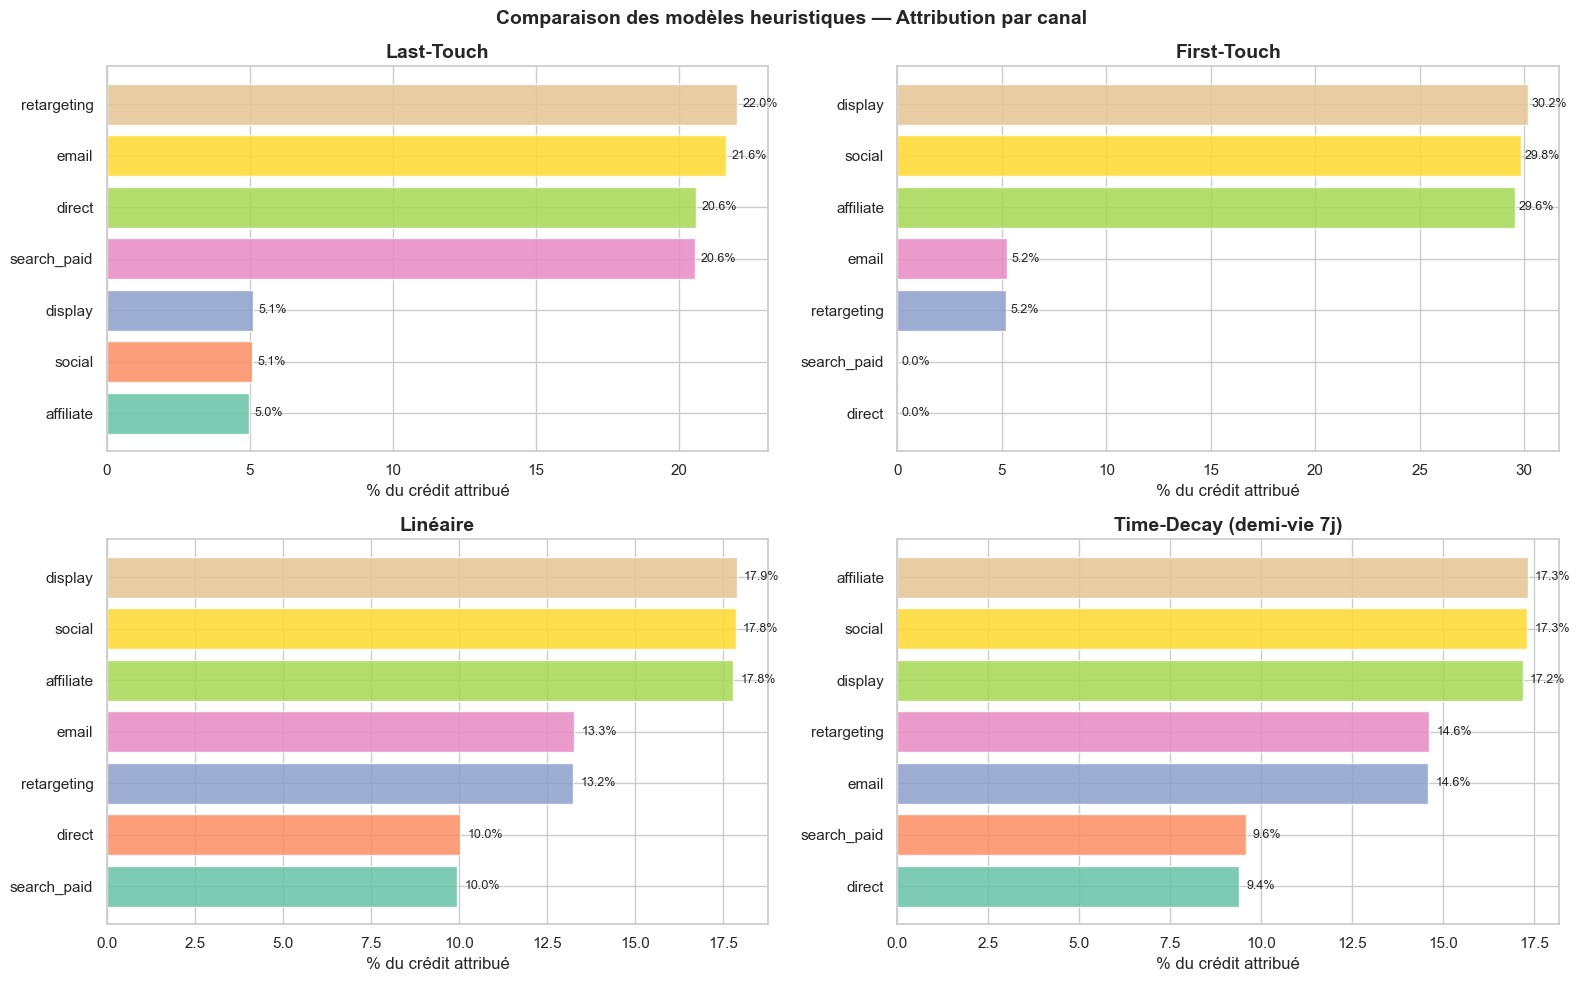

In [11]:
# Tableau comparatif des 4 modèles heuristiques
channels = sorted(touchpoints['channel'].unique())

attr_df = pd.DataFrame(index=channels)
attr_df['last_touch']  = last_touch_credits
attr_df['first_touch'] = first_touch_credits
attr_df['linear']      = linear_credits
attr_df['time_decay']  = decay_credits
attr_df = attr_df.fillna(0)

# Conversion en pourcentages
attr_pct = attr_df.div(attr_df.sum()) * 100

print("=== Attribution en % par modèle heuristique ===")
display(attr_pct.round(2))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
models = ['last_touch','first_touch','linear','time_decay']
titles = ['Last-Touch','First-Touch','Linéaire','Time-Decay (demi-vie 7j)']
palette = sns.color_palette('Set2', len(channels))

for ax, model, title in zip(axes, models, titles):
    vals = attr_pct[model].sort_values(ascending=True)
    ax.barh(vals.index, vals.values, color=palette, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('% du crédit attribué')
    for i, (idx, val) in enumerate(vals.items()):
        ax.text(val+0.2, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Comparaison des modèles heuristiques — Attribution par canal', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('heuristiques_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Étape 3 — Modèle de Markov <a id='etape3'></a>

Le modèle de Markov traite chaque parcours comme une chaîne d'états.
On calcule la **matrice de transition** entre canaux, puis on mesure
l'**effet de suppression** (removal effect) pour chaque canal.


### 3.1 Matrice de transition

Matrice de transition (extrait — lignes Start + canaux) :


,affiliate,direct,display,email,retargeting,search_paid,social,Conversion,Null
Start,0.2666,0.0000,0.2707,0.0976,0.0961,0.0000,0.2691,0.0000,0.0000
affiliate,0.1898,0.0737,0.1919,0.1169,0.1174,0.0745,0.1919,0.0048,0.0391
direct,0.0980,0.1488,0.0998,0.1577,0.1602,0.1462,0.0998,0.0894,0.0000
display,0.1931,0.0742,0.1893,0.1173,0.1160,0.0730,0.1932,0.0051,0.0387
email,0.1262,0.1162,0.1252,0.1443,0.1452,0.1159,0.1255,0.0696,0.0319
retargeting,0.1263,0.1159,0.1263,0.1450,0.1459,0.1160,0.1248,0.0693,0.0306
search_paid,0.1011,0.1465,0.0983,0.1585,0.1582,0.1469,0.1003,0.0901,0.0000
social,0.1907,0.0740,0.1924,0.1172,0.1175,0.0734,0.1906,0.0052,0.0391


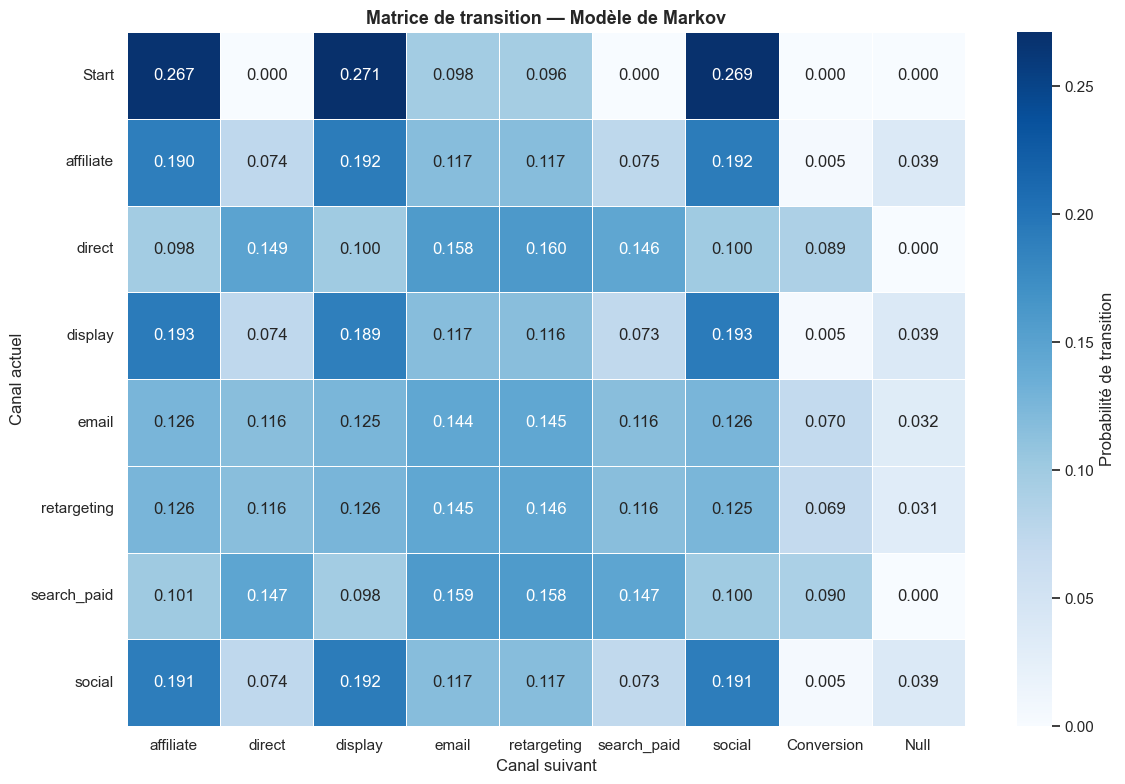

In [12]:
# Construction des parcours avec états Start / Conversion / Null
markov_paths = []

for cust_id, group in touchpoints.groupby('customer_id'):
    group = group.sort_values('position')
    # Tous les touchpoints du client
    channels_seq = group['channel'].tolist()
    converted_flag = group['converted'].max()

    path = ['Start'] + channels_seq
    if converted_flag == 1:
        path.append('Conversion')
    else:
        path.append('Null')
    markov_paths.append(path)

# Comptage des transitions
from collections import defaultdict
transition_counts = defaultdict(lambda: defaultdict(int))

for path in markov_paths:
    for i in range(len(path)-1):
        transition_counts[path[i]][path[i+1]] += 1

# Matrice de transition normalisée
all_states = ['Start'] + sorted(touchpoints['channel'].unique()) + ['Conversion','Null']

trans_matrix = pd.DataFrame(0.0, index=all_states, columns=all_states)
for src, targets in transition_counts.items():
    total = sum(targets.values())
    for tgt, count in targets.items():
        trans_matrix.loc[src, tgt] = count / total

print("Matrice de transition (extrait — lignes Start + canaux) :")
display(trans_matrix.drop(columns=['Start']).loc[
    ['Start'] + sorted(touchpoints['channel'].unique())
].round(4))

# Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
matrix_plot = trans_matrix.drop(index=['Conversion','Null'],
                                  columns=['Start']).round(3)
sns.heatmap(matrix_plot, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Probabilité de transition'})
ax.set_title('Matrice de transition — Modèle de Markov', fontweight='bold', fontsize=13)
ax.set_xlabel('Canal suivant'); ax.set_ylabel('Canal actuel')
plt.tight_layout()
plt.savefig('markov_transition.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Probabilité de conversion de base

In [13]:
# Calculer la probabilité de conversion globale par simulation sur la matrice
# P(Conversion) à partir de Start

def conversion_probability(trans_matrix, excluded_channel=None):
    """
    Calcule la probabilité de conversion par itération sur la matrice de Markov.
    Si excluded_channel est fourni, on retire ce canal (removal effect).
    """
    states = [s for s in trans_matrix.index
              if s not in ['Conversion','Null','Start']
              and s != excluded_channel]

    # Matrice de transition entre états transients uniquement
    Q = trans_matrix.loc[states, states].values
    # Vecteur d'absorption vers Conversion
    R_conv = trans_matrix.loc[states, 'Conversion'].values
    # Distribution initiale depuis Start
    start_to_states = trans_matrix.loc['Start', states].values

    # Résoudre (I - Q) * N = I (matrice fondamentale)
    I = np.eye(len(states))
    try:
        N = np.linalg.inv(I - Q)
    except np.linalg.LinAlgError:
        return 0.0

    # Probabilité d'absorption = N * R_conv
    absorption = N @ R_conv
    # Probabilité de conversion depuis Start
    p_conv = start_to_states @ absorption
    return p_conv

p_base = conversion_probability(trans_matrix)
print(f"Probabilité de conversion de base (modèle Markov) : {p_base:.4f} ({p_base*100:.2f}%)")
print()
print("Note : cette probabilité est calculée par résolution algébrique de la chaîne de Markov,")
print("pas par comptage direct — elle reflète la structure des transitions entre canaux.")

Probabilité de conversion de base (modèle Markov) : 0.5802 (58.02%)

Note : cette probabilité est calculée par résolution algébrique de la chaîne de Markov,
pas par comptage direct — elle reflète la structure des transitions entre canaux.


### 3.3 Effet de suppression (Removal Effect)

=== Removal Effect par canal ===
(Plus la valeur est élevée, plus le canal est critique)


,p_avec,p_sans,baisse_abs,removal_effect
display,0.5802,0.1426,0.4376,0.7543
social,0.5802,0.1426,0.4376,0.7542
affiliate,0.5802,0.1433,0.4369,0.7530
email,0.5802,0.1451,0.4351,0.7499
retargeting,0.5802,0.1453,0.4349,0.7495
direct,0.5802,0.2001,0.3801,0.6552
search_paid,0.5802,0.2002,0.3800,0.6549



=== Attribution Markov (en % basé sur removal effect) ===


,removal_effect,markov_pct
display,0.7543,14.87
social,0.7542,14.87
affiliate,0.7530,14.85
email,0.7499,14.79
retargeting,0.7495,14.78
direct,0.6552,12.92
search_paid,0.6549,12.91


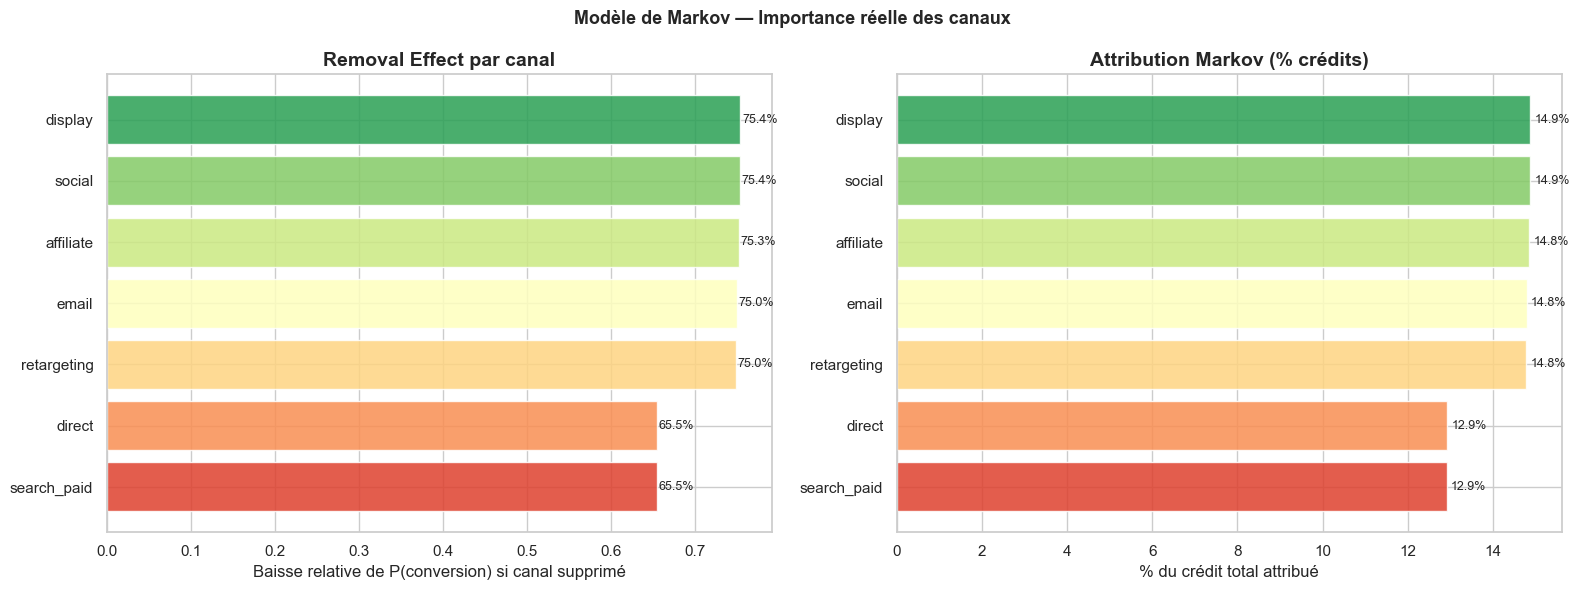

In [14]:
# Removal effect : pour chaque canal, calculer la baisse de P(conversion) si supprimé
channels_list = sorted(touchpoints['channel'].unique())
removal_effects = {}

for channel in channels_list:
    p_without = conversion_probability(trans_matrix, excluded_channel=channel)
    removal = (p_base - p_without) / p_base
    removal_effects[channel] = {
        'p_avec'    : p_base,
        'p_sans'    : p_without,
        'baisse_abs': p_base - p_without,
        'removal_effect': removal
    }

removal_df = pd.DataFrame(removal_effects).T.sort_values('removal_effect', ascending=False)
removal_df = removal_df.round(4)

print("=== Removal Effect par canal ===")
print("(Plus la valeur est élevée, plus le canal est critique)")
display(removal_df)

# Attribution Markov : proportionnel au removal effect
removal_df['markov_credit_raw'] = removal_df['removal_effect'].clip(lower=0)
removal_df['markov_pct'] = (removal_df['markov_credit_raw'] /
                             removal_df['markov_credit_raw'].sum() * 100).round(2)

print("\n=== Attribution Markov (en % basé sur removal effect) ===")
display(removal_df[['removal_effect','markov_pct']].sort_values('markov_pct', ascending=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette_re = sns.color_palette('RdYlGn', len(channels_list))
sorted_re = removal_df.sort_values('removal_effect', ascending=True)

axes[0].barh(sorted_re.index, sorted_re['removal_effect'],
             color=palette_re, alpha=0.85, edgecolor='white')
axes[0].set_title('Removal Effect par canal', fontweight='bold')
axes[0].set_xlabel('Baisse relative de P(conversion) si canal supprimé')
for i, (idx, val) in enumerate(sorted_re['removal_effect'].items()):
    axes[0].text(val+0.002, i, f'{val*100:.1f}%', va='center', fontsize=9)

sorted_mp = removal_df.sort_values('markov_pct', ascending=True)
axes[1].barh(sorted_mp.index, sorted_mp['markov_pct'],
             color=palette_re, alpha=0.85, edgecolor='white')
axes[1].set_title('Attribution Markov (% crédits)', fontweight='bold')
axes[1].set_xlabel('% du crédit total attribué')
for i, (idx, val) in enumerate(sorted_mp['markov_pct'].items()):
    axes[1].text(val+0.1, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Modèle de Markov — Importance réelle des canaux', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('markov_removal.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Étape 4 — Comparaison et analyse <a id='etape4'></a>

### 4.1 Tableau comparatif tous modèles


=== Attribution (%) par canal selon chaque modèle ===


,last_touch,first_touch,linear,time_decay,markov
display,5.12,30.16,17.88,17.19,14.87
social,5.07,29.83,17.85,17.31,14.87
affiliate,4.96,29.55,17.77,17.33,14.85
email,21.64,5.24,13.27,14.59,14.79
retargeting,22.03,5.22,13.24,14.62,14.78
direct,20.61,0.00,10.03,9.39,12.92
search_paid,20.56,0.00,9.95,9.58,12.91


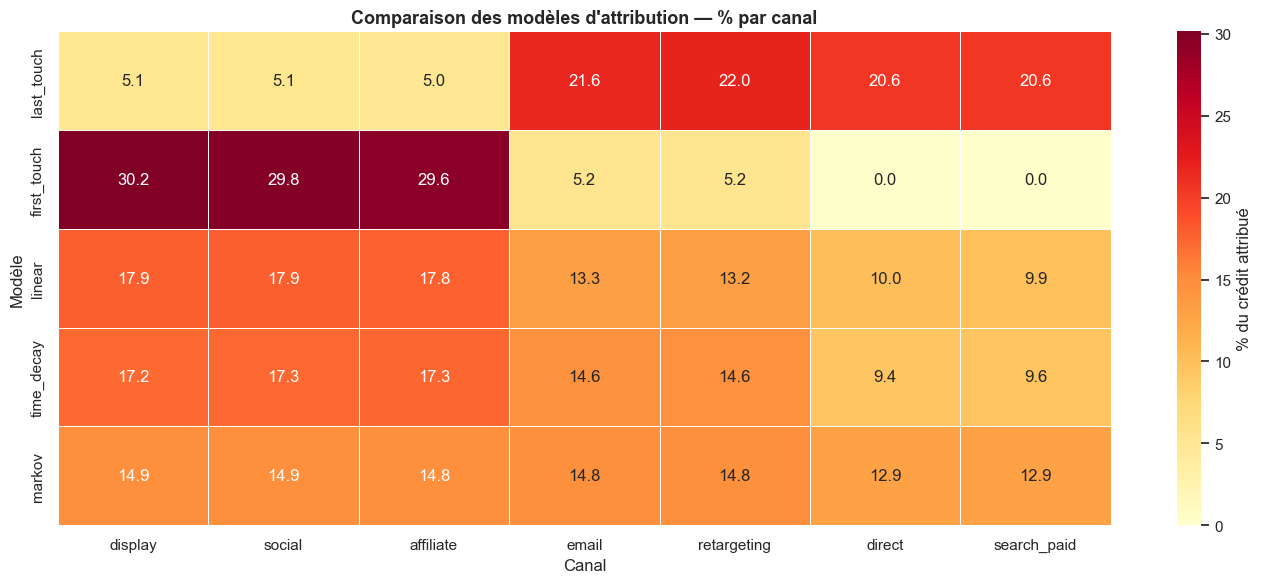

In [15]:
# Tableau comparatif : Last-touch, First-touch, Linéaire, Time-decay, Markov
comparison = attr_pct.copy()
comparison['markov'] = removal_df['markov_pct']
comparison = comparison.fillna(0).round(2)

# Tri par attribution Markov décroissante
comparison = comparison.sort_values('markov', ascending=False)

print("=== Attribution (%) par canal selon chaque modèle ===")
display(comparison)

# Heatmap comparative
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(comparison.T, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '% du crédit attribué'})
ax.set_title("Comparaison des modèles d'attribution — % par canal", fontweight='bold', fontsize=13)
ax.set_xlabel('Canal'); ax.set_ylabel('Modèle')
plt.tight_layout()
plt.savefig('comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Canaux sur-évalués par le last-touch

=== Canaux sur/sous-évalués par le last-touch vs Markov ===


,last_touch,markov,delta_last_vs_markov,statut
direct,20.61,12.92,7.69,Sur-évalué
search_paid,20.56,12.91,7.65,Sur-évalué
retargeting,22.03,14.78,7.25,Sur-évalué
email,21.64,14.79,6.85,Sur-évalué
display,5.12,14.87,-9.75,Sous-évalué
social,5.07,14.87,-9.80,Sous-évalué
affiliate,4.96,14.85,-9.89,Sous-évalué


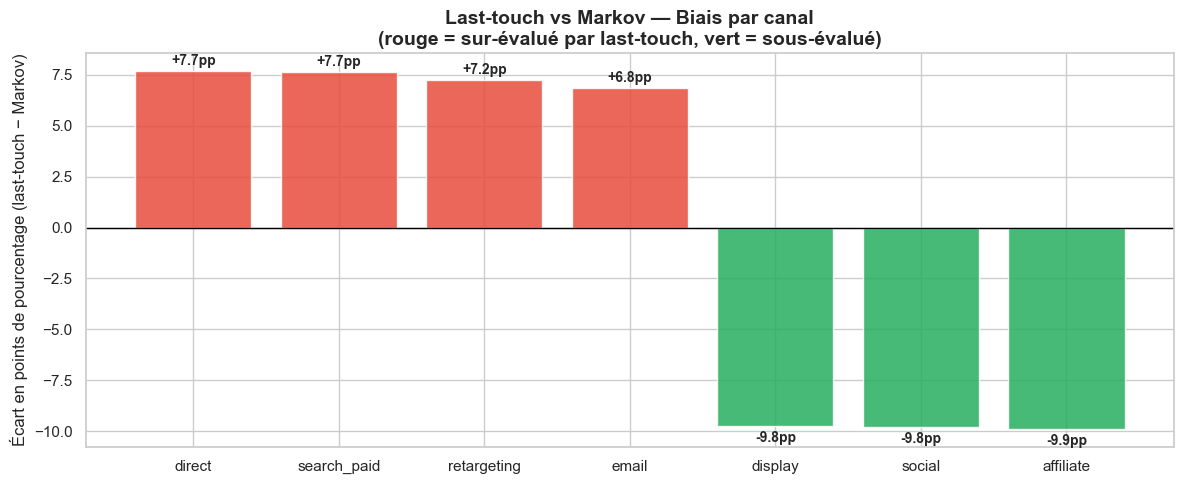


Conclusion :
  Canaux sur-évalués par last-touch  : ['email', 'retargeting', 'direct', 'search_paid']
  Canaux sous-évalués par last-touch : ['display', 'social', 'affiliate']


In [16]:
# Delta last-touch vs Markov : positif = sur-évalué, négatif = sous-évalué
comparison['delta_last_vs_markov'] = (comparison['last_touch'] - comparison['markov']).round(2)
comparison['statut'] = comparison['delta_last_vs_markov'].apply(
    lambda x: ' Sur-évalué' if x > 2 else (' Sous-évalué' if x < -2 else ' Neutre')
)

print("=== Canaux sur/sous-évalués par le last-touch vs Markov ===")
display(comparison[['last_touch','markov','delta_last_vs_markov','statut']].sort_values(
    'delta_last_vs_markov', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
delta = comparison['delta_last_vs_markov'].sort_values(ascending=False)
colors_delta = ['#e74c3c' if v > 0 else '#27ae60' for v in delta.values]
bars = ax.bar(delta.index, delta.values, color=colors_delta, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
for bar, val in zip(bars, delta.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + (0.3 if val >= 0 else -0.8),
            f'{val:+.1f}pp', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Last-touch vs Markov — Biais par canal\n(rouge = sur-évalué par last-touch, vert = sous-évalué)',
             fontweight='bold')
ax.set_ylabel('Écart en points de pourcentage (last-touch − Markov)')
plt.tight_layout()
plt.savefig('delta_last_markov.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConclusion :")
over  = comparison[comparison['statut']==' Sur-évalué'].index.tolist()
under = comparison[comparison['statut']==' Sous-évalué'].index.tolist()
print(f"  Canaux sur-évalués par last-touch  : {over}")
print(f"  Canaux sous-évalués par last-touch : {under}")

---
## Étape 5 — KPIs par canal et campagne <a id='etape5'></a>

### 5.1 KPIs opérationnels par canal


In [17]:
# Coût total par canal
cost_by_channel = touchpoints.groupby('channel')['cost'].sum()

# Conversions last-touch par canal (pour CVR et CAC last-touch)
conv_last = last_touch_credits.rename('conv_last_touch')

# Conversions Markov par canal (proportionnel au removal effect)
total_conversions = touchpoints['converted'].sum()
conv_markov = (removal_df['markov_pct'] / 100 * total_conversions).rename('conv_markov')

# CA attribué par Markov
# Hypothèse : on répartit le CA total selon l'attribution Markov
ca_total_campagnes = campaigns['estimated_revenue'].sum()

kpis = pd.DataFrame(index=channels_list)
kpis['cost_total']       = cost_by_channel
kpis['conv_last_touch']  = conv_last
kpis['conv_markov']      = conv_markov
kpis['ca_markov']        = (removal_df['markov_pct'] / 100 * ca_total_campagnes)
kpis = kpis.fillna(0)

# ROAS last-touch
ca_last = (last_touch_credits / last_touch_credits.sum() * ca_total_campagnes)
kpis['ca_last_touch'] = ca_last.fillna(0)
kpis['roas_last_touch'] = (kpis['ca_last_touch'] / kpis['cost_total'].replace(0, np.nan)).round(2)
kpis['roas_markov']     = (kpis['ca_markov']     / kpis['cost_total'].replace(0, np.nan)).round(2)

# CAC Markov = coût / conversions attribuées
kpis['cac_markov'] = (kpis['cost_total'] / kpis['conv_markov'].replace(0, np.nan)).round(2)

# CVR par canal = conversions / touchpoints
tp_count = touchpoints.groupby('channel')['touchpoint_id'].count()
kpis['n_touchpoints'] = tp_count
kpis['cvr_pct'] = (touchpoints.groupby('channel')['converted'].mean() * 100).round(2)

print("=== KPIs par canal ===")
display(kpis[['cost_total','conv_last_touch','conv_markov','roas_last_touch',
              'roas_markov','cac_markov','cvr_pct']].round(2))

=== KPIs par canal ===


,cost_total,conv_last_touch,conv_markov,roas_last_touch,roas_markov,cac_markov,cvr_pct
affiliate,240050.75,2410.0,14715.76,2.28,6.82,16.31,0.00
direct,0.00,10009.0,12803.20,NaN,NaN,0.00,35.46
display,60734.21,2485.0,14735.58,9.29,26.99,4.12,0.00
email,4852.57,10510.0,14656.30,491.65,335.95,0.33,25.58
retargeting,87451.85,10697.0,14646.39,27.77,18.63,5.97,25.75
search_paid,83459.70,9983.0,12793.29,27.15,17.05,6.52,35.52
social,96459.75,2463.0,14735.58,5.80,16.99,6.55,0.00


### 5.2 ROAS last-touch vs ROAS Markov

=== ROAS Last-touch vs ROAS Markov ===
(L'écart est l'argument pour changer de modèle d'attribution)


,roas_last_touch,roas_markov
email,491.65,335.95
display,9.29,26.99
retargeting,27.77,18.63
search_paid,27.15,17.05
social,5.80,16.99
affiliate,2.28,6.82


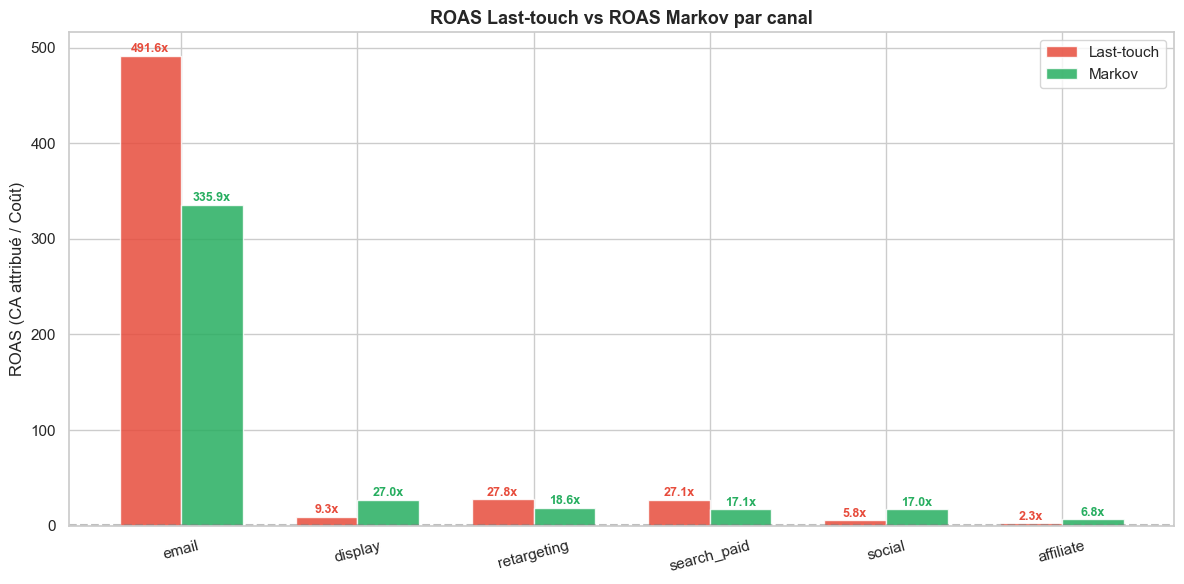

In [18]:
# Comparaison ROAS : l'argument central pour le CMO
roas_comp = kpis[['roas_last_touch','roas_markov']].dropna().sort_values('roas_markov', ascending=False)

print("=== ROAS Last-touch vs ROAS Markov ===")
print("(L'écart est l'argument pour changer de modèle d'attribution)")
display(roas_comp.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(roas_comp))
w = 0.35
bars1 = ax.bar(x - w/2, roas_comp['roas_last_touch'], w, label='Last-touch',
               color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, roas_comp['roas_markov'], w, label='Markov',
               color='#27ae60', alpha=0.85, edgecolor='white')

for bar in bars1:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}x',
                ha='center', va='bottom', fontsize=9, color='#e74c3c', fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}x',
                ha='center', va='bottom', fontsize=9, color='#27ae60', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(roas_comp.index, rotation=15)
ax.set_title('ROAS Last-touch vs ROAS Markov par canal', fontweight='bold', fontsize=13)
ax.set_ylabel('ROAS (CA attribué / Coût)')
ax.legend()
ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
plt.tight_layout()
plt.savefig('roas_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 CPA par campagne

=== CPA et ROAS par campagne (données campaigns.csv) ===


,campaign_name,n_clients,n_conversions,conversion_rate,cpa,roas,estimated_revenue
0,Back_to_School_2023,28490,19562,0.69,1.72,69.20,2322968.00
1,Black_Friday_2023,28495,19467,0.68,1.73,69.14,2329075.80
2,Spring_Launch_2024,28373,19436,0.68,1.71,62.65,2078515.27
3,Summer_Sale_2023,28451,19597,0.69,1.70,56.45,1880754.02
5,Winter_Promo_2023,28478,19596,0.69,1.71,49.10,1642104.94
4,Valentine_2024,28316,19475,0.69,1.69,23.40,768982.47


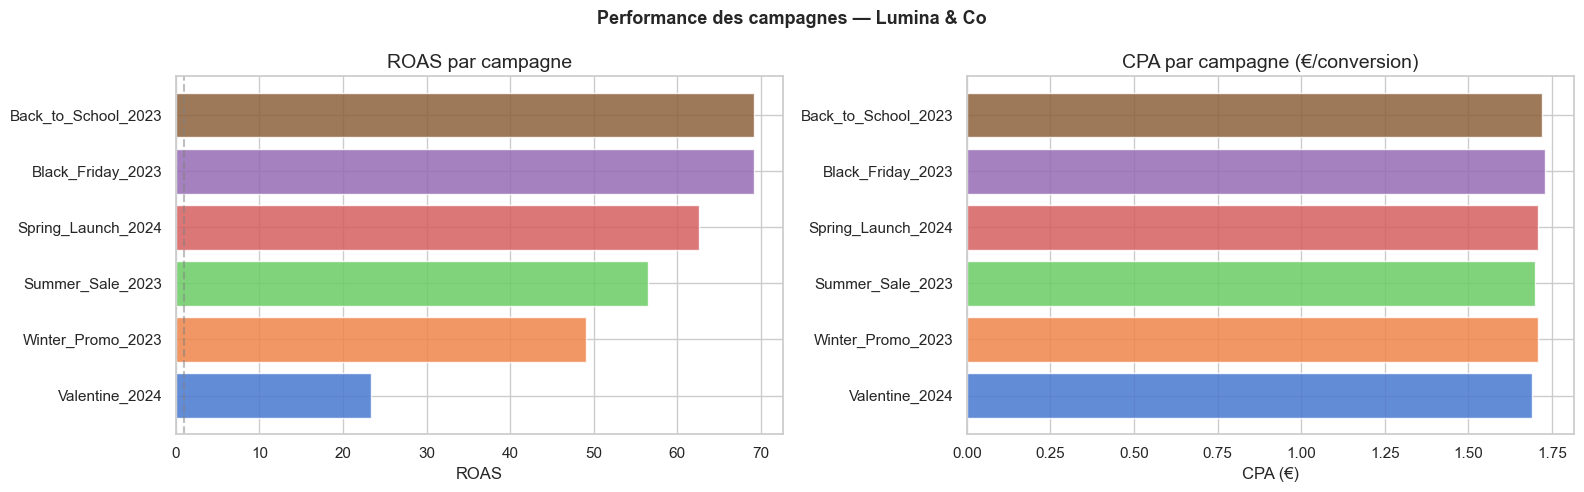

In [19]:
# CPA par campagne depuis campaigns.csv
print("=== CPA et ROAS par campagne (données campaigns.csv) ===")
camp_kpis = campaigns[['campaign_name','n_clients','n_conversions',
                        'conversion_rate','cpa','roas','estimated_revenue']].copy()
camp_kpis = camp_kpis.sort_values('roas', ascending=False)
display(camp_kpis.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette_c = sns.color_palette('muted', len(camp_kpis))

axes[0].barh(camp_kpis['campaign_name'][::-1], camp_kpis['roas'][::-1],
             color=palette_c, alpha=0.85, edgecolor='white')
axes[0].set_title('ROAS par campagne')
axes[0].set_xlabel('ROAS')
axes[0].axvline(1, color='gray', linestyle='--', alpha=0.5)

axes[1].barh(camp_kpis['campaign_name'][::-1], camp_kpis['cpa'][::-1],
             color=palette_c, alpha=0.85, edgecolor='white')
axes[1].set_title('CPA par campagne (€/conversion)')
axes[1].set_xlabel('CPA (€)')

plt.suptitle('Performance des campagnes — Lumina & Co', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('camp_kpis.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Recommandations budgétaires — Question CMO

> *"Vous êtes CMO. Avec les données de votre modèle Markov, quel canal mérite +20% de budget ?
> Quel canal doit être réduit ? Justifiez avec les chiffres."*


In [20]:
# Identifier les canaux à augmenter et à réduire
# Critères : ROAS Markov élevé + sous-évalué par last-touch = augmenter
#            ROAS Markov faible + sur-évalué par last-touch = réduire

reco = kpis[['cost_total','roas_markov','cvr_pct','cac_markov']].copy()
reco['markov_pct']            = removal_df['markov_pct']
reco['last_touch_pct']        = attr_pct['last_touch']
reco['delta_last_vs_markov']  = reco['last_touch_pct'] - reco['markov_pct']

# Score composite : ROAS Markov normalisé - sur-évaluation last-touch
roas_norm = (reco['roas_markov'] - reco['roas_markov'].min()) /             (reco['roas_markov'].max() - reco['roas_markov'].min())
delta_norm = (reco['delta_last_vs_markov'] - reco['delta_last_vs_markov'].min()) /              (reco['delta_last_vs_markov'].max() - reco['delta_last_vs_markov'].min())
reco['score_budget'] = roas_norm - delta_norm  # haut = à augmenter

reco = reco.sort_values('score_budget', ascending=False)

print("=" * 65)
print("RECOMMANDATIONS BUDGÉTAIRES — MODÈLE MARKOV")
print("=" * 65)
print()

top_canal    = reco.index[0]
bottom_canal = reco.index[-1]

top_row = reco.loc[top_canal]
bot_row = reco.loc[bottom_canal]

print(f" CANAL À AUGMENTER (+20% budget) : {top_canal.upper()}")
print(f"   ROAS Markov      : {top_row['roas_markov']:.1f}x")
print(f"   CVR              : {top_row['cvr_pct']:.1f}%")
print(f"   CAC              : {top_row['cac_markov']:.2f}€")
print(f"   Attribution Markov : {top_row['markov_pct']:.1f}% vs Last-touch : {top_row['last_touch_pct']:.1f}%")
print(f"   → Sous-évalué de {top_row['delta_last_vs_markov']:.1f}pp par last-touch")
print()
print(f" CANAL À RÉDUIRE (-20% budget) : {bottom_canal.upper()}")
print(f"   ROAS Markov      : {bot_row['roas_markov']:.1f}x")
print(f"   CVR              : {bot_row['cvr_pct']:.1f}%")
print(f"   CAC              : {bot_row['cac_markov']:.2f}€")
print(f"   Attribution Markov : {bot_row['markov_pct']:.1f}% vs Last-touch : {bot_row['last_touch_pct']:.1f}%")
print(f"   → Sur-évalué de {-bot_row['delta_last_vs_markov']:.1f}pp par last-touch")
print()
print("=" * 65)
print("CANAUX RÉHABILITÉS PAR MARKOV (sous-évalués par last-touch) :")
rehab = reco[reco['delta_last_vs_markov'] < -2].sort_values('delta_last_vs_markov')
for canal, row in rehab.iterrows():
    print(f"  {canal:15s} | Markov: {row['markov_pct']:.1f}% | Last-touch: {row['last_touch_pct']:.1f}% "
          f"| Écart: {row['delta_last_vs_markov']:+.1f}pp")

RECOMMANDATIONS BUDGÉTAIRES — MODÈLE MARKOV

 CANAL À AUGMENTER (+20% budget) : DISPLAY
   ROAS Markov      : 27.0x
   CVR              : 0.0%
   CAC              : 4.12€
   Attribution Markov : 14.9% vs Last-touch : 5.1%
   → Sous-évalué de -9.8pp par last-touch

 CANAL À RÉDUIRE (-20% budget) : DIRECT
   ROAS Markov      : nanx
   CVR              : 35.5%
   CAC              : 0.00€
   Attribution Markov : 12.9% vs Last-touch : 20.6%
   → Sur-évalué de -7.7pp par last-touch

CANAUX RÉHABILITÉS PAR MARKOV (sous-évalués par last-touch) :
  affiliate       | Markov: 14.8% | Last-touch: 5.0% | Écart: -9.9pp
  social          | Markov: 14.9% | Last-touch: 5.1% | Écart: -9.8pp
  display         | Markov: 14.9% | Last-touch: 5.1% | Écart: -9.8pp
